In [1]:
import src.Tomo3D as MuonTomo
from src.utils import *
from discretize import TensorMesh
from SimPEG import maps
# from pymatsolver import Pardiso
from collections import OrderedDict
import matplotlib.pyplot as plt
import matplotlib as mpl
import math

In [2]:
import requests
import io
import numpy as np

# Ensembles

In [3]:
RELOAD_ENSEMBLES = False

if RELOAD_ENSEMBLES:
    # load the prior state
    response = requests.get('https://www.dropbox.com/scl/fi/83nliurps84ifjs9inrv5/results_ensmeble_07022024.npy?rlkey=m3utsjmzhyvqocgimdjteiah5&dl=1')
    response.raise_for_status()
    m_ensemble = (np.load(io.BytesIO(response.content))>=0) * 1.0 # NOTE: .astype(float) by *1.0 is important

In [4]:
import matplotlib.pyplot as plt
import skfmm
import numpy as np
def orebody_plt_3D(orebody_3d, plt_title='', z_ticks = None):
    '''3D plot of orebody, by [] 
    input: 
    orebody_3D: a 3D array of 0-non ore,1-ore for the orebody'''
    m_sdf = skfmm.distance(orebody_3d-0.5)
    plt_contour = np.argwhere((m_sdf<2) & (m_sdf>=-0.5))
    if z_ticks ==None:
        z_ticks=np.arange(0,orebody_3d.shape[2]+1, orebody_3d.shape[2]/4).astype(int)
    
    
    ax = plt.figure(figsize=(7,7)).add_subplot(projection='3d')

    ax.scatter(plt_contour[:,0], 
               plt_contour[:,1],
               plt_contour[:,2], 
               c = 'y',
               linewidth=0.1,edgecolor='k',
               marker='s', vmax=1,
               s=25)
    ax.set_title(plt_title, fontsize=18)
    ax.set_xlim(0, m_sdf.shape[0]), ax.set_ylim(0, m_sdf.shape[1]), ax.set_zlim(0,m_sdf.shape[2])
    ax.set_xlabel('X dim', fontsize = 15); ax.set_ylabel('Y dim', fontsize = 15); ax.set_zlabel('Z dim', fontsize = 15)
    ax.xaxis.pane.set_edgecolor('k')
    ax.yaxis.pane.set_edgecolor('k')
    ax.zaxis.pane.set_edgecolor('k')
#     ax.set_zticks(-z_ticks)
#     plt.gca().invert_zaxis()
    return  

In [5]:
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # Use Latin Modern instead
    "font.size": 12,
})

In [6]:
# load ground model
response = requests.get('https://www.dropbox.com/scl/fi/yt4d3xb3mj5v00trnhx3u/ground_truth_80x80x60.npy?rlkey=qo6hrni4sidp9nryy234g8zq5&dl=1')
response.raise_for_status()
true_intrusion = np.load(io.BytesIO(response.content))
true_intrusion = np.nan_to_num(true_intrusion)
# load topography
response = requests.get('https://www.dropbox.com/scl/fi/lua5fwx9dwejml14u3bxp/topography.npy?rlkey=2mrl452k7u0ubn0vwzfp61gm6&dl=1')
response.raise_for_status()
topography = np.load(io.BytesIO(response.content))*10

# Input parameters

Model dimension parameters

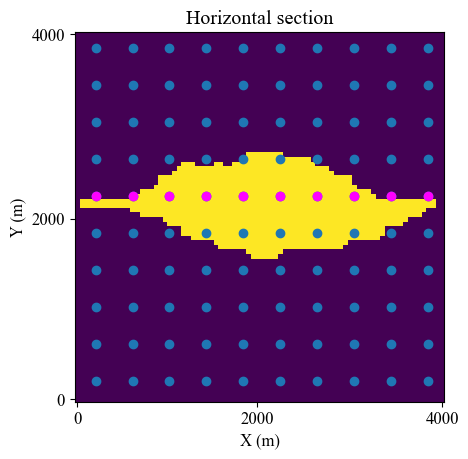

In [7]:
# dimension of the mesh
x_dim, y_dim, z_dim = true_intrusion.shape
n= (x_dim, y_dim, z_dim)
# scale of the mesh
hx, hy, hz = 50.0, 50.0, 10.0 # meters
h = np.array([hx, hy, hz])
x0 = np.array([0., 0., -480.])

# create mask for topography
topo_mask = true_intrusion.copy()
topo_mask[topo_mask==0] = True
topo_mask[topo_mask==1] = True

# density model, with intrusion density = 1.5, background density 1 and air density 0
dens_intr = 1.5 # intrusive rock
dens_hst = 1 # host rock

hole_nx, hole_ny = 10, 10
xbh, ybh = np.meshgrid(np.linspace(200,3800, hole_nx), 
                       np.linspace(200,3800, hole_ny))
xbh, ybh = xbh.flatten(), ybh.flatten()
zbh = np.array([snap_to_topo((xbh[i], ybh[i],0), topography, x0, h, n)[2] for i in range(len(xbh))])
dips = 180.0 + np.full_like(zbh, 60.0) #np.tile([20, 90+70], 4)
azimuth = 90.0
lengths = np.repeat(1100, hole_nx*hole_ny) # borehole length
bhs = [Borehole((xbh[i], ybh[i], zbh[i]), dips[i], azimuth, lengths[i], i) for i in range(len(xbh))]
plt.imshow((true_intrusion*topo_mask)[:,:,-12].T, origin='lower')
plt.xticks([0,39, 79], [0, 2000, 4000]), plt.yticks([0,39, 79], [0, 2000, 4000])
plt.ylabel('Y (m)'), plt.xlabel('X (m)')
plt.title('Horizontal section')
plt.scatter(xbh / hx, ybh / hy)
plt.scatter(xbh[50:60] / hx, ybh[50:60] / hy, c="magenta") 

/tmp/ipykernel_1979613/2650094462.py:16: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmax' will be ignored
  ax.scatter(plt_contour[:,0],


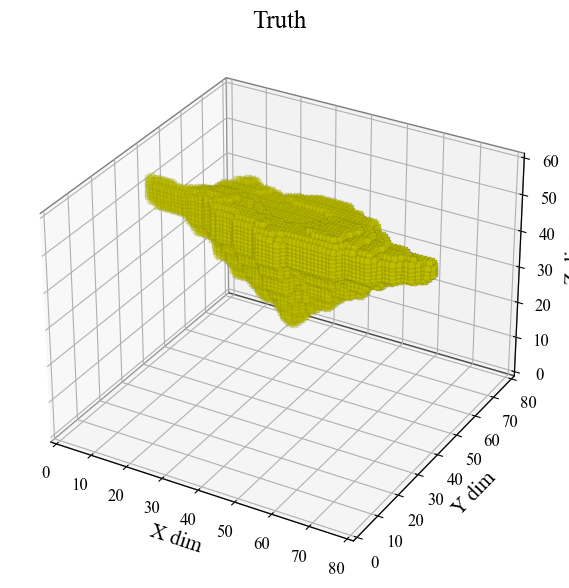

In [8]:
orebody_plt_3D(true_intrusion,  plt_title='Truth')

/tmp/ipykernel_138029/2650094462.py:16: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmax' will be ignored
  ax.scatter(plt_contour[:,0],


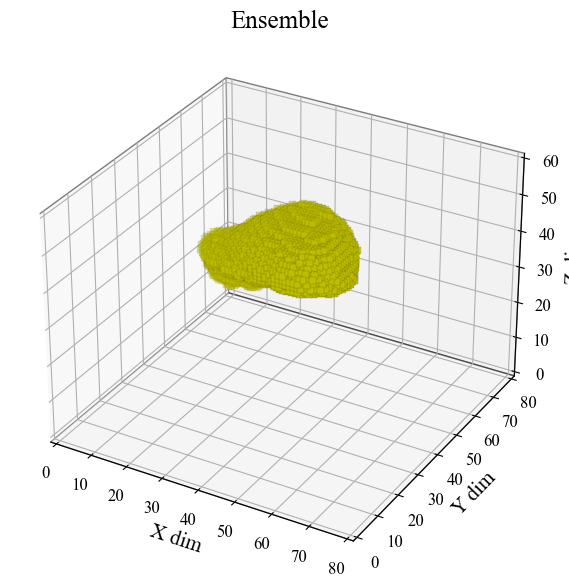

In [9]:
orebody_plt_3D(m_ensemble[400].reshape(80,80,60),  plt_title='Ensemble')

In [9]:
from matplotlib.colors import LinearSegmentedColormap
colors = ["#44342a", "#e1e697"]  # Dark brown to tan (#3E1F00 to #D2B48C)
cmap = LinearSegmentedColormap.from_list("brown_to_tan", colors, N=256)

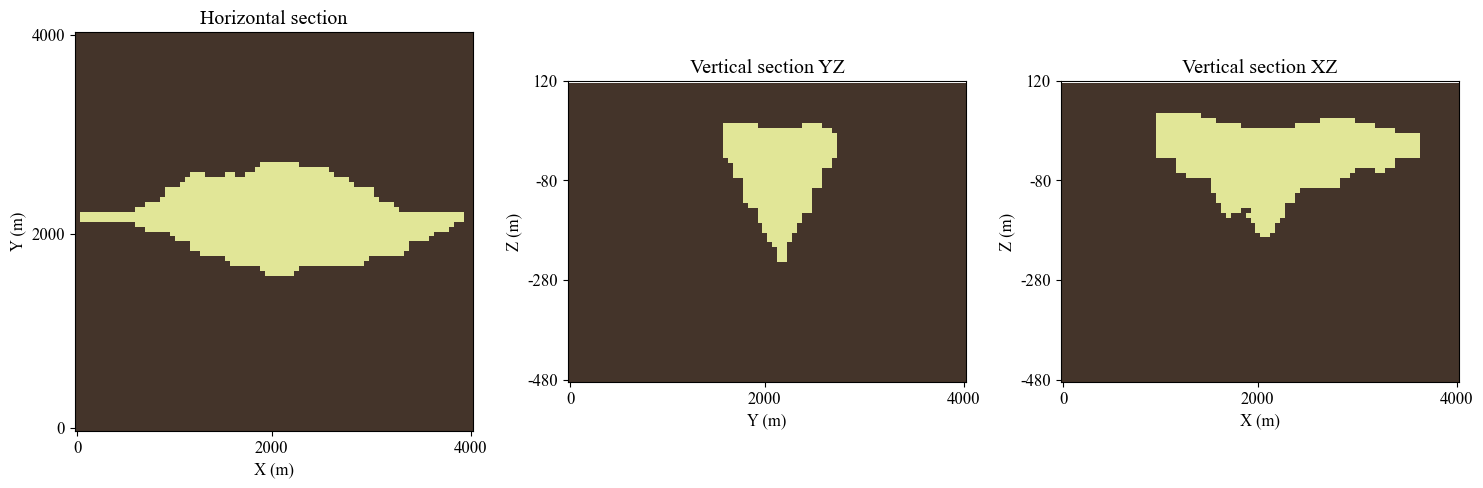

In [10]:
plt.figure(figsize=(15,7))
plt.subplot(131)
plt.imshow((true_intrusion*topo_mask)[:,:,-12].T, origin='lower', cmap=cmap)
plt.xticks([0,39, 79], [0, 2000, 4000]), plt.yticks([0,39, 79], [0, 2000, 4000])
plt.ylabel('Y (m)'), plt.xlabel('X (m)')
plt.title('Horizontal section')
plt.subplot(132)
plt.imshow((true_intrusion*topo_mask)[39].T, origin='lower', cmap=cmap)
plt.xticks([0,39, 79], [0, 2000, 4000]), plt.yticks([0,20, 40, 60], [-480, -280, -80, 120])
plt.ylabel('Z (m)'), plt.xlabel('Y (m)')
plt.title('Vertical section YZ')
plt.subplot(133)
img = plt.imshow((true_intrusion*topo_mask)[:,39].T, origin='lower', cmap=cmap)
# for bh in bhs:
    # plt.plot((bh.x0[0]-x0[0])/hx, (bh.x0[2]-x0[2])/hz, 'r*', markersize=10)
# plt.colorbar(img, ax=plt.gca(), orientation='vertical')
plt.xticks([0,39, 79], [0, 2000, 4000]), plt.yticks([0,20, 40, 60], [-480, -280, -80, 120])
plt.ylabel('Z (m)'), plt.xlabel('X (m)')
plt.title('Vertical section XZ')
plt.tight_layout()

In [11]:
top_x = np.argwhere(topography)[:,0]
top_y = np.argwhere(topography)[:,1]
top_z = topography[np.argwhere(topography)[:,0], np.argwhere(topography)[:,1]]
# create x, y, z array
top_xyz = np.c_[top_x[:-1]*50+25, top_y[:-1]*50+25, top_z[:-1]] # use cell center only

In [12]:
import random

In [13]:
plt.style.use('dark_background')

/tmp/ipykernel_1979613/2855311598.py:7: MatplotlibDeprecationWarning: The w_xaxis attribute was deprecated in Matplotlib 3.1 and will be removed in 3.8. Use xaxis instead.
  ax.w_xaxis.set_pane_color(colors[0])
/tmp/ipykernel_1979613/2855311598.py:8: MatplotlibDeprecationWarning: The w_yaxis attribute was deprecated in Matplotlib 3.1 and will be removed in 3.8. Use yaxis instead.
  ax.w_yaxis.set_pane_color(colors[0])
/tmp/ipykernel_1979613/2855311598.py:9: MatplotlibDeprecationWarning: The w_zaxis attribute was deprecated in Matplotlib 3.1 and will be removed in 3.8. Use zaxis instead.
  ax.w_zaxis.set_pane_color(colors[0])
/tmp/ipykernel_1979613/2855311598.py:11: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmax' will be ignored
  ax.scatter(plt_contour[:,0],


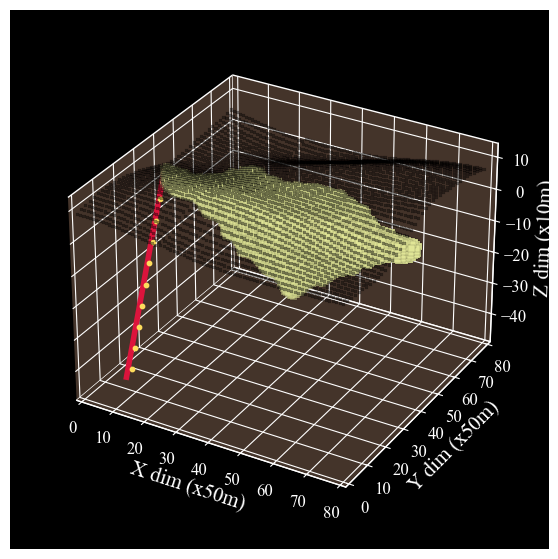

In [14]:
m_sdf = skfmm.distance(true_intrusion-0.5)
plt_contour = np.argwhere((m_sdf<2) & (m_sdf>=-0.5))

fig = plt.figure(figsize=(7,7))
fig.patch.set_alpha(0)
ax = fig.add_subplot(projection='3d')
ax.w_xaxis.set_pane_color(colors[0])
ax.w_yaxis.set_pane_color(colors[0])
ax.w_zaxis.set_pane_color(colors[0])

ax.scatter(plt_contour[:,0],
           plt_contour[:,1],
           plt_contour[:,2]-48,
           c = colors[-1],
           linewidth=0.1, edgecolor='k',
           marker='s', vmax=1,
           # alpha=0.025,
           s=25)
ax.scatter(top_x[::2], top_y[::2], (top_z/10)[::2],
           c = 'k',
           linewidth=0.15, edgecolor='k',
           marker='s', alpha=0.4,
           s=5)

# # Plot boreholes and sensor locations
random.seed(1)
# random.seed(4) # center with `how_many_to_show = 1` and `alpha=0.025` above

how_many_to_show = 1
showing = 0
for (ibh, rij) in enumerate(bhs):
    if random.random() < 0.95 or how_many_to_show <= showing:
        continue
    showing += 1
    ix0, iy0, iz0 = get_cell_index(rij.x0, x0, h, n)
    # ix1, iy1, iz1 = get_cell_index(rij(lengths[ibh]), x0, h, n)
    p = rij(lengths[ibh])
    ix = int(np.floor((p[0] - x0[0])/h[0]))
    # assert ix >= 0 and ix < n[0], "x index out of bounds"
    iy = int(np.floor((p[1] - x0[1])/h[1]))
    # assert iy >= 0 and iy < n[1], f"y index out of bounds: {iy}"
    iz = int(np.floor((p[2] - x0[2])/h[2]))
    # assert iz >= 0 and iz < n[2], "z index out of bounds"
    ix1 = ix
    iy1 = iy
    iz1 = iz
    ax.plot([ix0, ix1], [iy0, iy1], [iz0-48, iz1-48], linewidth=4, c='crimson')
    n_sensors_per_bh = 9
    for ti in np.linspace(150.0, lengths[ibh]-2.5*h[2], n_sensors_per_bh):
        loc = rij(ti) - x0
        ax.scatter(loc[0]/h[0], loc[1]/h[1], loc[2]/h[2]-48, c='#FEDD5C', marker='o', s=10)

ax.set_xlim(0, m_sdf.shape[0]), ax.set_ylim(0, m_sdf.shape[1]), ax.set_zlim(-48, 13)
ax.set_xlabel('X dim (x50m)', fontsize = 15)
ax.set_ylabel('Y dim (x50m)', fontsize = 15)
ax.set_zlabel('Z dim (x10m)', fontsize = 15)
ax.xaxis.pane.set_edgecolor('white')
ax.yaxis.pane.set_edgecolor('white')
ax.zaxis.pane.set_edgecolor('white')

ax.set_box_aspect(aspect=None, zoom=0.89)
# same y, different x (vertical boreholes, not angels (viz. component))

# plt.savefig(f"3d-{how_many_to_show}-center.png", transparent=True)
plt.savefig(f"3d-{how_many_to_show}.png", transparent=True)

# Define the forward model of Muon data

In [558]:
# Create a discretize tensor mesh
mesh = TensorMesh([[hi] * ni for (hi,ni) in zip(h,n)], x0=np.array([0,0,-480.0]))

# Create radiograph grid specifying the grid of ray directions
# along which opacities will be computed.
tan_theta_max = np.tan(np.radians(60))
nx = 20; ny = 20
xgrid = np.linspace(-tan_theta_max, tan_theta_max, nx)
ygrid = np.linspace(-tan_theta_max, tan_theta_max, ny)

# Create muon sensors
sensors = OrderedDict()
n_sensors_per_bh = 9
sensor_locs = np.zeros((len(bhs)*n_sensors_per_bh, 3))
for (ibh, bh) in enumerate(bhs):
    for (i,ti) in enumerate(np.linspace(150.0, lengths[ibh]-2.5*h[2], n_sensors_per_bh)):
        loc = bh(ti)
        sensor_locs[bh.id*n_sensors_per_bh+i] = loc
        sensors[f'{bh.id}_{i}'] = MuonTomo.MuonSensor(loc, xgrid, ygrid)

# Define active cell mapping, for later use in SimPEG inversion
# SimPEG inversion will work on all cells above the lowest sensor and
# below the topography. Forward operator will be applied to all cells
# after mapping the active cell model to the full mesh.
minz = np.min(sensor_locs[:,2])
gridCC = mesh.gridCC
is_active = np.logical_not(np.isnan(topo_mask))
is_active = is_active.flatten(order='F')
is_active = np.logical_and(is_active, gridCC[:,2] >= minz - h[2])
active_map = maps.InjectActiveCells(mesh, is_active, valInactive=0.0)

In [559]:
for bh in bhs:
    if bh.x0[0] == 200:
    # if bh.x0[1] == 2600:
        print(f"{bh.id}: {bh.x0}")

0: (200.0, 200.0, 90.0)
10: (200.0, 600.0, 100.0)
20: (200.0, 1000.0, 90.0)
30: (200.0, 1400.0, 80.0)
40: (200.0, 1800.0, 60.0)
50: (200.0, 2200.0, 30.0)
60: (200.0, 2600.0, 20.0)
70: (200.0, 3000.0, 30.0)
80: (200.0, 3400.0, 30.0)
90: (200.0, 3800.0, 30.0)


In [560]:
import pickle

In [561]:
def save_sim(obj, filename='muon_sim_simpeg.pkl'):
    with open(filename, 'wb') as f:
        pickle.dump(obj, f)

In [562]:
def load_sim(filename='muon_sim_simpeg.pkl'):
    with open(filename, 'rb') as f:
        obj = pickle.load(f)
    return obj

In [655]:
# Generate forward operator
# We wrap the forwad operator in a SimPEG simulation object
# for use in SimPEG inversion routines. To access the underlying
# scipy sparse matrix forward operator, use the attribute muon_sim_simpeg._G

RERUN = False

if RERUN:
    print('It will take around 20min. Once need to run once', )  
    muon_sim_simpeg = MuonTomo.ToyMuonSimulationSimPeg(mesh, sensors, model_map=active_map)
    save_sim(muon_sim_simpeg)
else:
    muon_sim_simpeg = load_sim()    

In [565]:
# Run forward model on the ground truth geological model
## assign the model variable
model = true_intrusion.copy()
dens_m = np.zeros_like(model) # create density model
dens_m[true_intrusion==1] = dens_intr
dens_m[true_intrusion==0] = dens_hst
## Run forward model to get muon sensor data
d_muon = muon_sim_simpeg.get_data(dens_m.flatten(order='F')[is_active])

In [566]:
def normalize(ordered_dict):
    # Find the global minimum and maximum across all arrays
    all_values = np.concatenate(list(ordered_dict.values()))
    global_min = np.min(all_values)
    global_max = np.max(all_values)
    
    # Avoid division by zero if global_max == global_min
    normalized_dict = OrderedDict()
    if global_max != global_min:
        for key, array in ordered_dict.items():
            normalized_array = (array - global_min) / (global_max - global_min)
            normalized_dict[key] = normalized_array
    else:
        # If all values are the same, return arrays of zeros
        for key, array in ordered_dict.items():
            normalized_dict[key] = np.zeros_like(array)
    
    return normalized_dict

In [567]:
def divide_ordered_dicts(dict1, dict2):
    result_dict = OrderedDict()
    
    for key in dict1.keys():
        # Element-wise division of corresponding arrays
        result_dict[key] = dict1[key] / dict2[key]
    
    return result_dict

In [644]:
def generate_muon(state, topography, rerun=False, avg_density=False):
    # density model, with intrusion density = 1.5, background density 1 and air density 0
    dens_intr = 1.5 # intrusive rock
    dens_hst = 1.0  # host rock

    # Run forward model on the ground truth geological model
    model = state.copy()
    dens_m = np.zeros_like(model) # create density model
    dens_m[model==1] = dens_intr
    dens_m[model==0] = dens_hst

    # create mask for topography
    topo_mask = state.copy()
    topo_mask[topo_mask==0] = True
    topo_mask[topo_mask==1] = True

    # dimension of the mesh
    x_dim, y_dim, z_dim = state.shape
    n = (x_dim, y_dim, z_dim)

    # scale of the mesh
    hx, hy, hz = 50.0, 50.0, 10.0 # meters
    h = np.array([hx, hy, hz])
    x0 = np.array([0., 0., -480.])
    hole_nx, hole_ny = 10, 10

    xbh, ybh = np.meshgrid(np.linspace(200,3800, hole_nx), 
                           np.linspace(200,3800, hole_ny))
    xbh, ybh = xbh.flatten(), ybh.flatten()
    zbh = np.array([snap_to_topo((xbh[i], ybh[i],0), topography, x0, h, n)[2] for i in range(len(xbh))])

    dips = 180.0 + np.full_like(zbh, 60.0)
    azimuth = 90.0
    lengths = np.repeat(1100, hole_nx*hole_ny) # borehole length

    bhs = [Borehole((xbh[i], ybh[i], zbh[i]), dips[i], azimuth, lengths[i], i) for i in range(len(xbh))]

    # Create a discretize tensor mesh
    mesh = TensorMesh([[hi] * ni for (hi,ni) in zip(h,n)], x0=np.array([0,0,-480.0]))

    # Create radiograph grid specifying the grid of ray directions
    # along which opacities will be computed.
    tan_theta_max = np.tan(np.radians(60))
    nx = 20
    ny = 20

    if rerun:
        xgrid = np.linspace(-tan_theta_max, tan_theta_max, nx)
        ygrid = np.linspace(-tan_theta_max, tan_theta_max, ny)
        # Create muon sensors
        sensors = OrderedDict()

    n_sensors_per_bh = 9
    sensor_locs = np.zeros((len(bhs)*n_sensors_per_bh, 3))
    for (ibh, bh) in enumerate(bhs):
        for (i,ti) in enumerate(np.linspace(150.0, lengths[ibh]-2.5*h[2], n_sensors_per_bh)):
            loc = bh(ti)
            sensor_locs[bh.id*n_sensors_per_bh+i] = loc
            if rerun:
                sensors[f'{bh.id}_{i}'] = MuonTomo.MuonSensor(loc, xgrid, ygrid)

    # Define active cell mapping, for later use in SimPEG inversion
    # SimPEG inversion will work on all cells above the lowest sensor and
    # below the topography. Forward operator will be applied to all cells
    # after mapping the active cell model to the full mesh.
    minz = np.min(sensor_locs[:,2])
    gridCC = mesh.gridCC
    is_active = np.logical_not(np.isnan(topo_mask))
    is_active = is_active.flatten(order='F')
    is_active = np.logical_and(is_active, gridCC[:,2] >= minz - h[2])

    if rerun:
        print('It will take around 5-20min. Once need to run once')
        active_map = maps.InjectActiveCells(mesh, is_active, valInactive=0.0)
        muon_sim_simpeg = MuonTomo.ToyMuonSimulationSimPeg(mesh, sensors, model_map=active_map)
        save_sim(muon_sim_simpeg)
    else:
        muon_sim_simpeg = load_sim()    
        
    # Run forward model to get muon sensor data
    d_muon = muon_sim_simpeg.get_data(dens_m.flatten(order='F')[is_active])

    if avg_density:
        # Null model (no intrusion) with density of 1 for demonstration purposes
        rho0 = np.ones(mesh.nC)

        # Forward model the null model
        d0_muon = muon_sim_simpeg.get_data(rho0[is_active])

        return divide_ordered_dicts(normalize(d_muon), normalize(d0_muon))
    else:
        return normalize(d_muon)

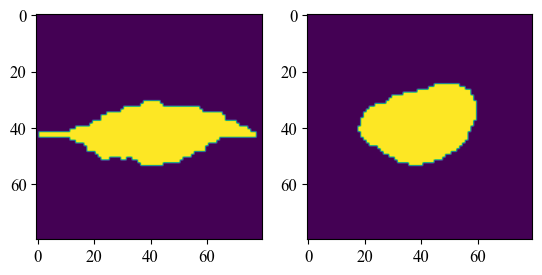

In [665]:
plt.subplots(1,2)
plt.subplot(1,2,1)
plt.imshow(np.mean(true_intrusion, axis=2).T > 0.0)
plt.subplot(1,2,2)
plt.imshow(np.mean(m_ensemble[400].reshape(80,80,60), axis=2).T > 0.0)

In [258]:
std_muon = OrderedDict([(k, 0.005*v) for (k,v) in d_muon.items()])

Save the muon data to .json file

In [261]:
list(range(5, 100, 10))

[5, 15, 25, 35, 45, 55, 65, 75, 85, 95]

In [660]:
def plot_radiographs(d_muon):
    # Plot null model radiographs: (null = empty space, only topography without intrusion inside)
    nx = 20
    ny = 20
    plt.subplots(9,10,figsize=(30, 20))
    c = 0
    for j in range(0, 9):
        for i in range(60, 70):
        # for i in range(5, 100, 10):
            c += 1
            data_id = f"{i}_{j}"
            data_arr = d_muon[data_id]
            plt.subplot(9,10,c)
            ax = plt.gca()
            img = ax.imshow(data_arr.reshape(nx, ny).T, cmap="viridis", origin="lower") # NOTE: .T transpose is important
            ax.set_title(f"Radiograph, Sensor {data_id}", fontsize=10)
            ax.set_xticks([])
            ax.set_yticks([])
            # ax.axis('off')
            cbar = plt.colorbar(img, ax=ax)
            cbar.ax.tick_params(labelsize=8)

    plt.show()

In [659]:
def plot_radiographs_all(d_muon, sliced=False):
    # Plot null model radiographs: (null = empty space, only topography without intrusion inside)
    nx = 20
    ny = 20
    if sliced:
        plt.subplots(1,10,figsize=(30, 20))
        xy = range(60, 70)
    else:
        plt.subplots(10,10,figsize=(30, 20))
        # xy = range(0, 100)
        xy = [num for i in range(90, -1, -10) for num in range(i, i + 10)]
    for i,ri in enumerate(xy):
        m = np.zeros((nx, ny))
        for j in range(0, 9):
            data_id = f"{ri}_{j}"
            data_arr = d_muon[data_id]
            m += data_arr.reshape(nx,ny)
        m /= 9
        if sliced:
            plt.subplot(1,10,i+1)
        else:
            plt.subplot(10,10,i+1)
        ax = plt.gca()
        img = ax.imshow(m.T, cmap="viridis", origin="lower") # NOTE: .T transpose is important
        ax.set_title(f"{ri}", fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])
        # ax.axis('off')
        cbar = plt.colorbar(img, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=8)

    plt.show()

In [443]:
def get_muon_observation(true_muon, x, y):
    ax = ay = 10
    az = 9
    xy2ind = np.array(list(true_muon.keys())).reshape(ax,ay,az)
    keys = xy2ind[y,x,:] # NOTE: y,x flipped
    k = keys[0]
    m = np.zeros(true_muon[k].shape)
    nx = ny = int(np.sqrt(m.shape[0]))
    for k in keys:
        m += true_muon[k]
    m /= az
    return m.reshape(nx,ny).T # NOTE: Transpose is important

In [667]:
# d_muon_test = generate_muon(m_ensemble[400].reshape(80,80,60), topography, avg_density=True)
d_muon_test = generate_muon(true_intrusion, topography, avg_density=True)

/tmp/ipykernel_3251003/3558672140.py:6: RuntimeWarning: invalid value encountered in divide
  result_dict[key] = dict1[key] / dict2[key]


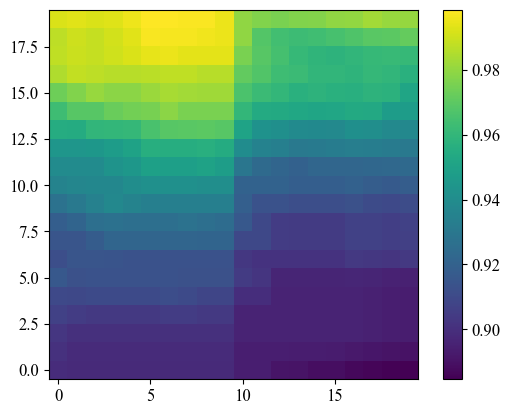

In [668]:
plt.figure()
plt.imshow(get_muon_observation(d_muon_test, 5, 5), origin="lower") # NOTE: origin="lower" important.
plt.colorbar()

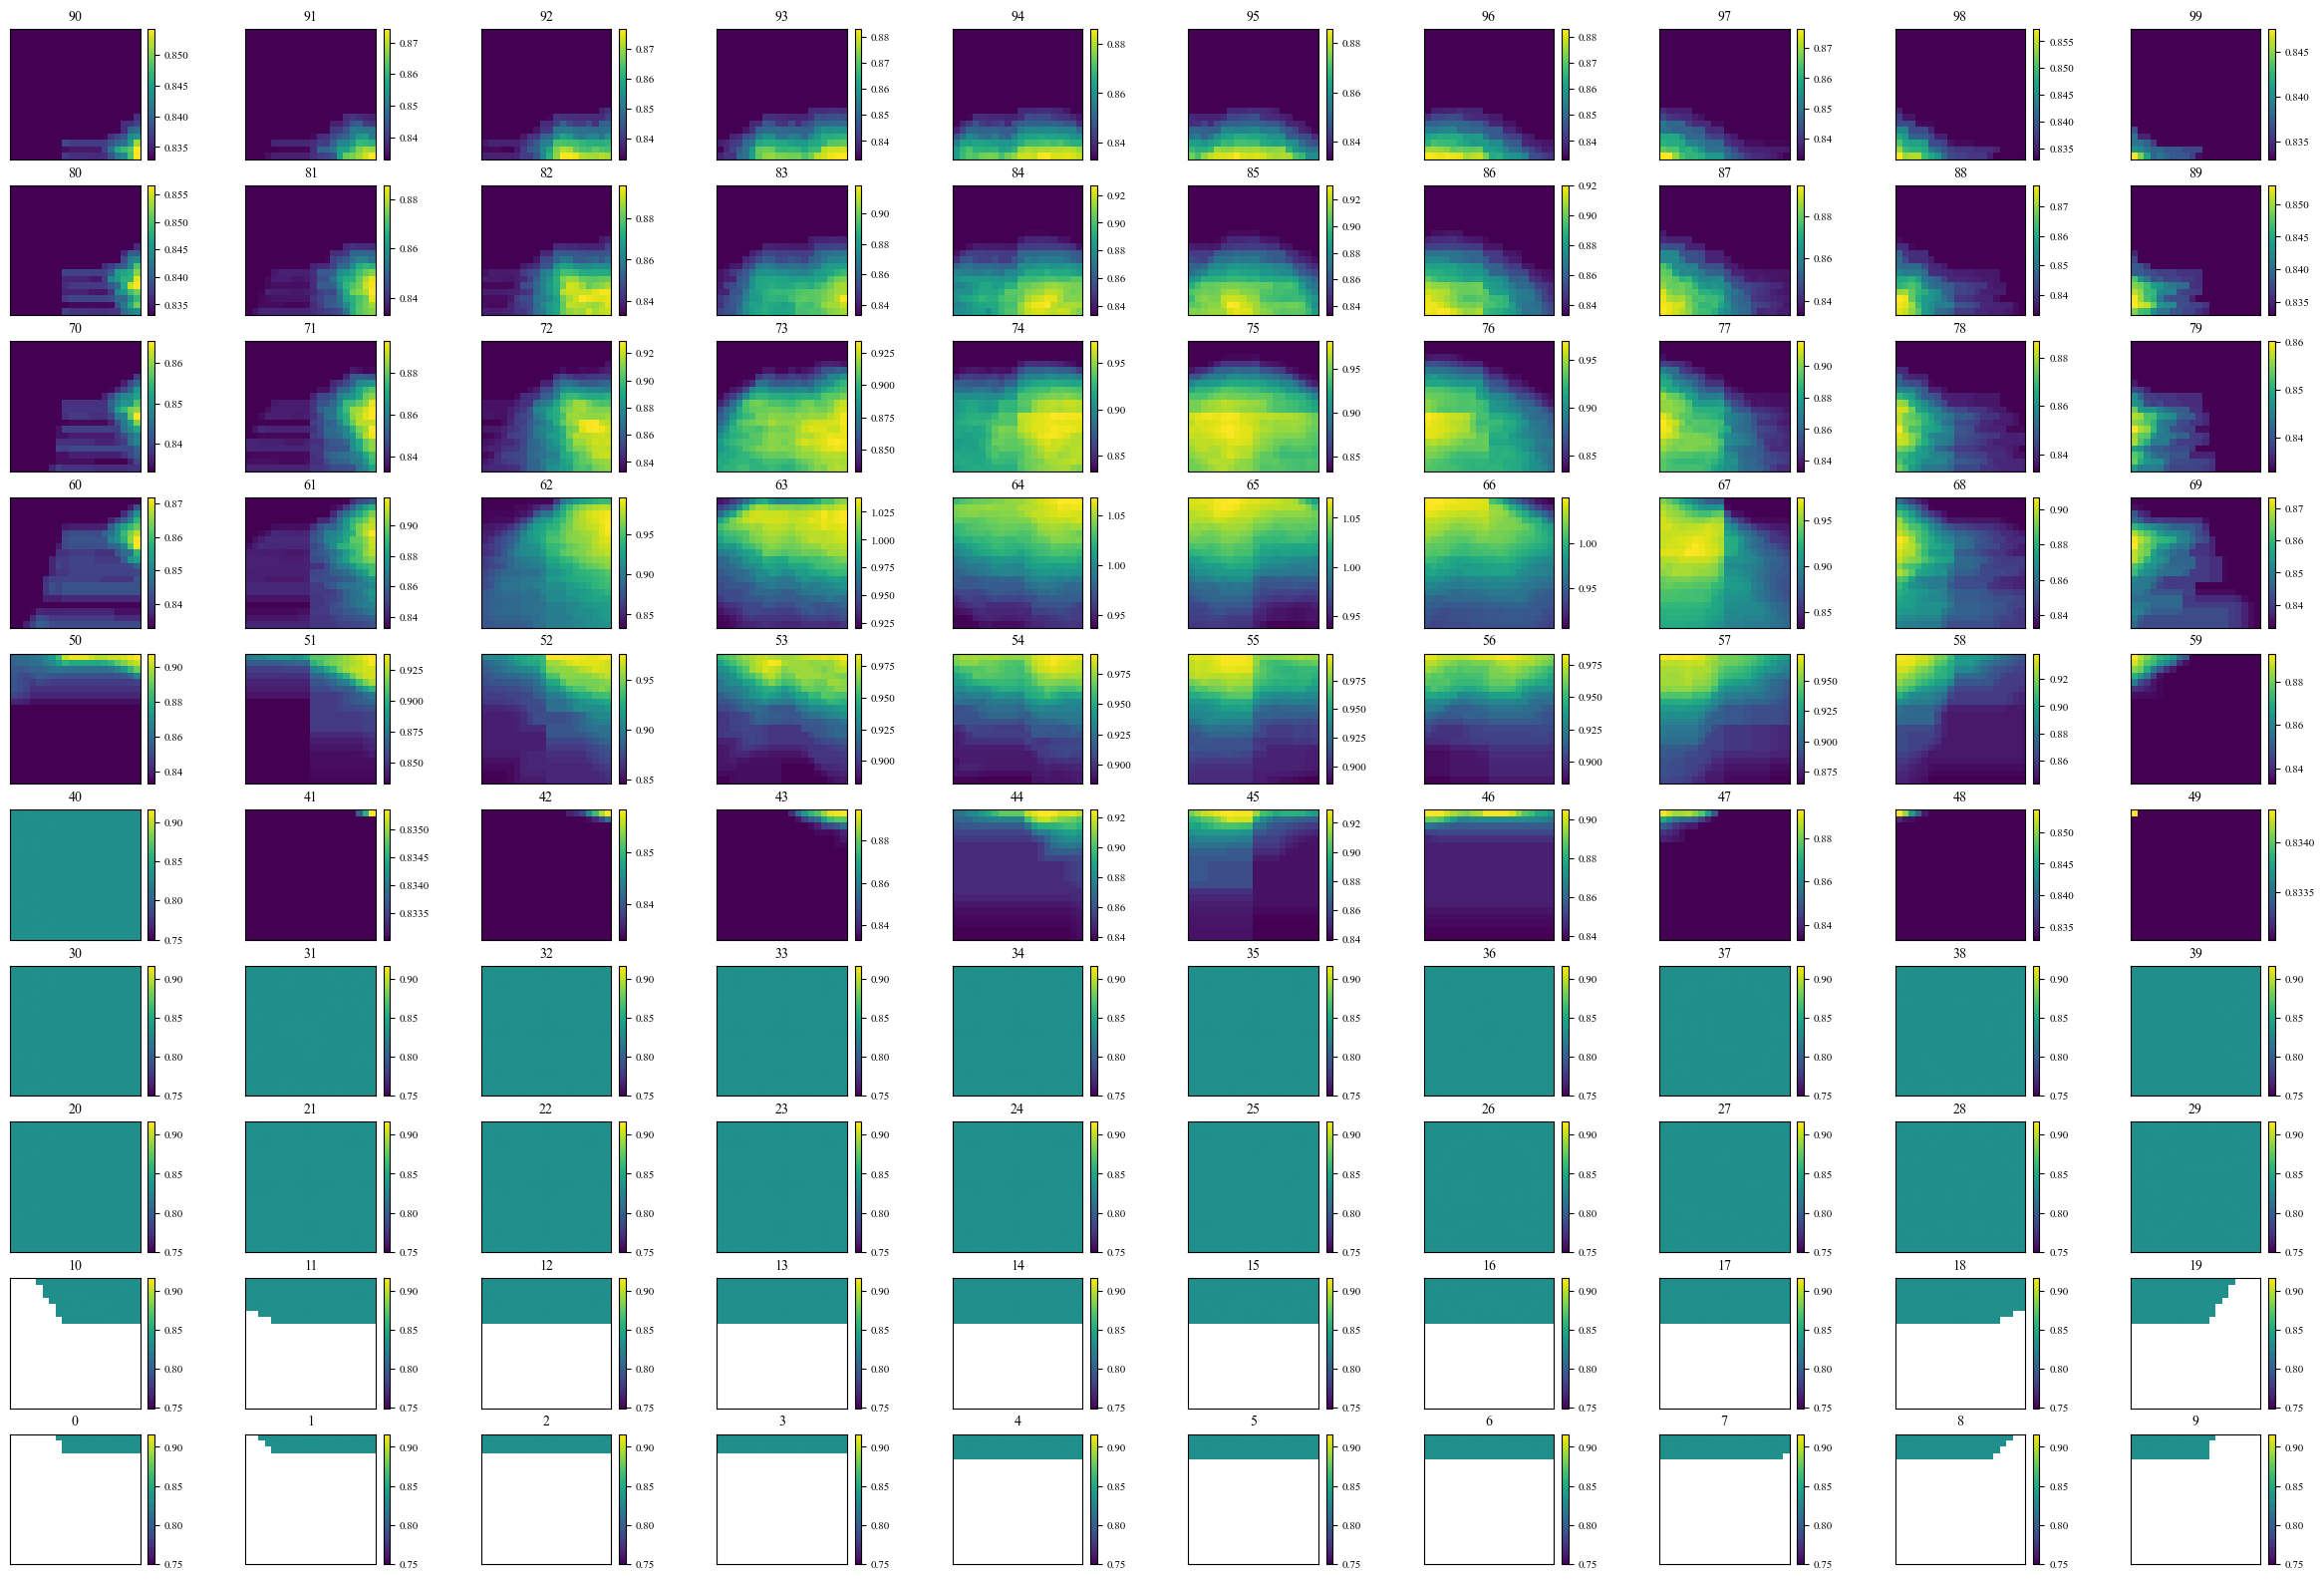

In [669]:
plot_radiographs_all(d_muon_test)

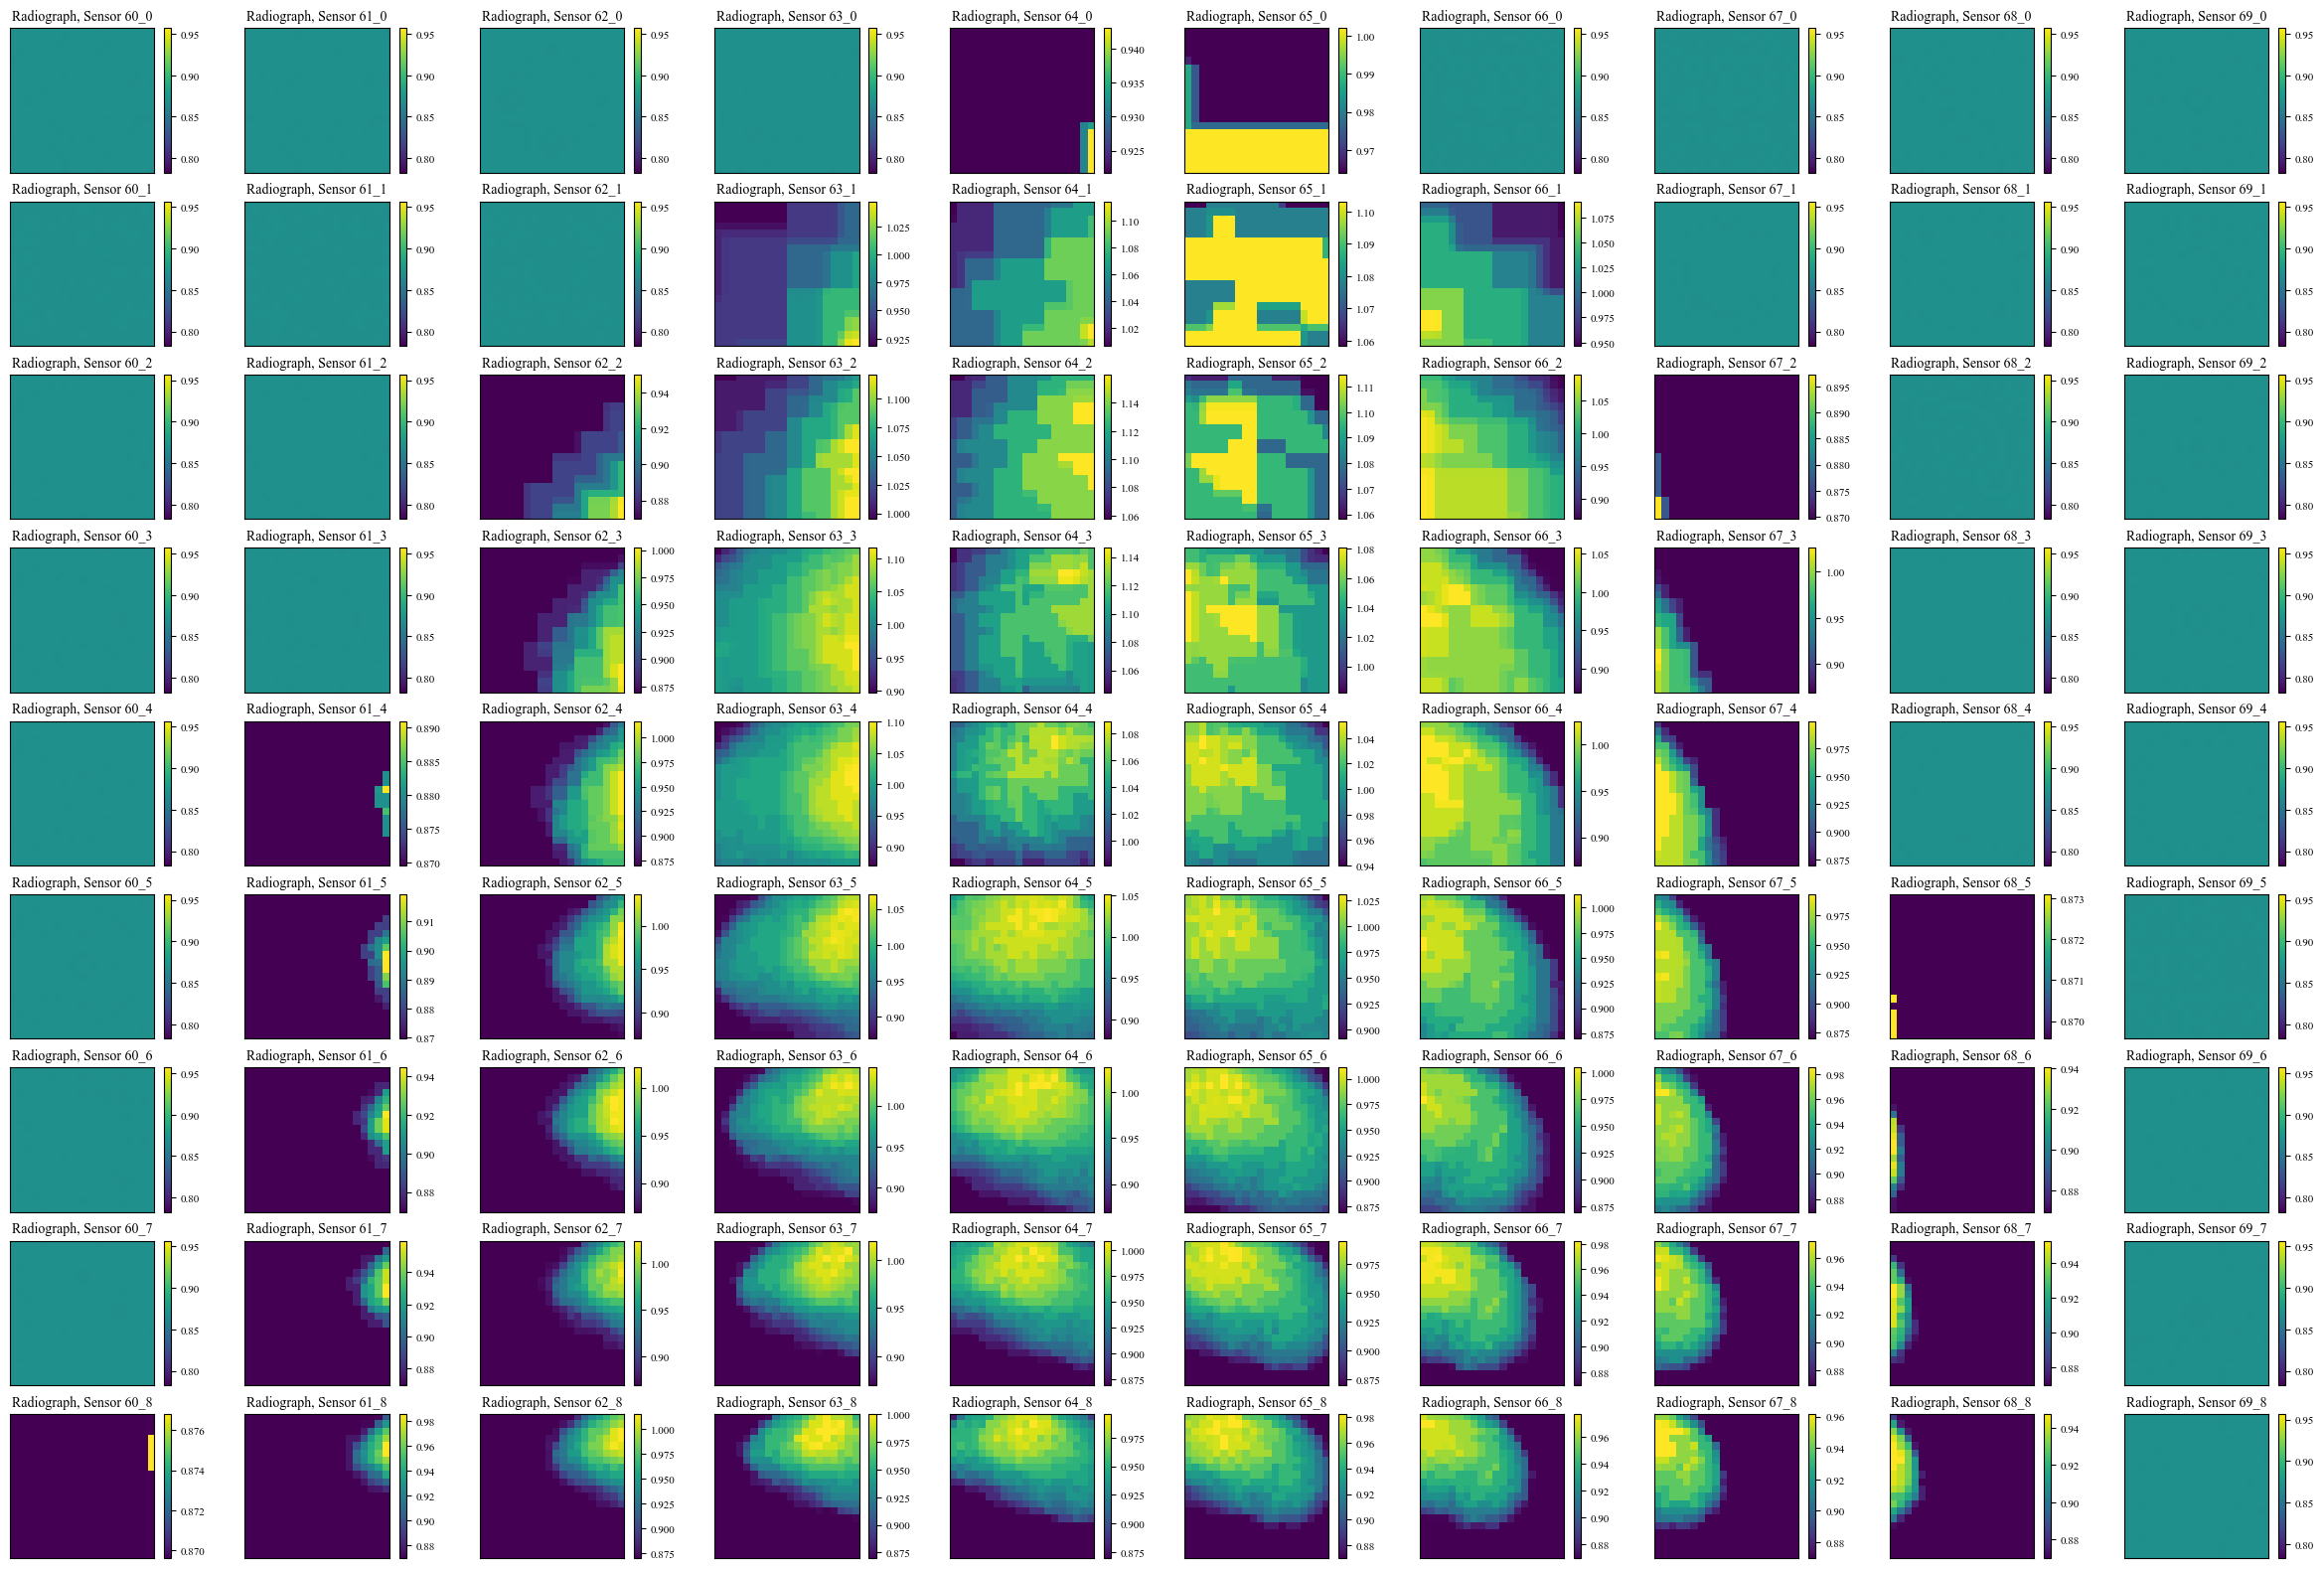

In [666]:
plot_radiographs(d_muon_test)

In [268]:
class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return json.JSONEncoder.default(self, obj)

NameError: name 'json' is not defined

In [35]:
d_fname = '100holes_moun'
with open(d_fname+str(i)+'.json', 'w') as f:
    f.write(json.dumps(d_muon,cls=NumpyEncoder))